# Blood Pressure Softmax Classification

## Load modules

In [1]:
# ============================================
# 1. 필요한 라이브러리 불러오기
# ============================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# numpy는 숫자 계산을 쉽게 하기 위해 사용합니다.
# tensorflow는 인공지능 모델을 만들고 학습시키기 위해 사용합니다.
# matplotlib은 학습 결과를 그래프로 보기 위해 사용합니다.

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.16.2
Matplotlib Version :3.10.0


## Input and Label

In [3]:
# ============================================
# 2. 입력 데이터와 정답 데이터 만들기
# ============================================

# x_input은 모델에게 넣어줄 입력값입니다.
# 여기서는 사람의 Age와 BMI를 입력값으로 사용합니다.
# 즉, 모델은 나이와 BMI를 보고 혈압 상태를 예측합니다.

# 첫 번째 값은 Age, 두 번째 값은 BMI입니다.
# 예: [25, 22]는 나이 25세, BMI 22라는 뜻입니다.

x_input = tf.constant([
    [25, 22], [25, 26], [25, 30],
    [35, 22], [35, 26], [35, 30],
    [45, 22], [45, 26], [45, 30],
    [55, 22], [55, 26], [55, 30],
    [65, 22], [65, 26], [65, 30],
    [73, 22], [73, 26], [73, 30]
], dtype=tf.float32)


# labels는 정답 데이터입니다.
# 여기서는 혈압 상태를 3가지 등급으로 나누었습니다.
#
# 0번 클래스: 정상
# 1번 클래스: 주의
# 2번 클래스: 경고
#
# 왜 혈압을 3개로 분류했을까?
# 혈압은 실제로 하나의 숫자로만 판단하기보다,
# 정상인지, 조금 위험한 상태인지, 위험한 상태인지처럼
# 단계별로 해석하는 경우가 많습니다.
#
# 예를 들어 병원에서도 혈압을 볼 때
# “정상입니다”
# “조금 조심해야 합니다”
# “위험하니 관리가 필요합니다”
# 처럼 등급으로 설명하는 경우가 많습니다.
#
# 그래서 이 예제에서는 혈압을 숫자로 예측하는 회귀 문제가 아니라,
# 정상, 주의, 경고 중 하나를 고르는 분류 문제로 만든 것입니다.


# labels는 one-hot encoding 방식으로 작성되어 있습니다.
#
# [1, 0, 0] → 정상
# [0, 1, 0] → 주의
# [0, 0, 1] → 경고
#
# 왜 이렇게 쓰는가?
# 컴퓨터는 “정상”, “주의”, “경고” 같은 글자를 바로 이해하지 못합니다.
# 그래서 각 상태를 숫자 배열로 바꾸어 표현합니다.

labels = tf.constant([
    [1, 0, 0],  # 25세, BMI 22 → 정상
    [0, 1, 0],  # 25세, BMI 26 → 주의
    [0, 0, 1],  # 25세, BMI 30 → 경고

    [1, 0, 0],  # 35세, BMI 22 → 정상
    [0, 1, 0],  # 35세, BMI 26 → 주의
    [1, 0, 0],  # 35세, BMI 30 → 정상

    [1, 0, 0],  # 45세, BMI 22 → 정상
    [1, 0, 0],  # 45세, BMI 26 → 정상
    [0, 1, 0],  # 45세, BMI 30 → 주의

    [1, 0, 0],  # 55세, BMI 22 → 정상
    [0, 1, 0],  # 55세, BMI 26 → 주의
    [0, 0, 1],  # 55세, BMI 30 → 경고

    [0, 1, 0],  # 65세, BMI 22 → 주의
    [0, 0, 1],  # 65세, BMI 26 → 경고
    [0, 0, 1],  # 65세, BMI 30 → 경고

    [0, 1, 0],  # 73세, BMI 22 → 주의
    [0, 0, 1],  # 73세, BMI 26 → 경고
    [0, 0, 1]   # 73세, BMI 30 → 경고
], dtype=tf.float32)


## Min Max Scaler

In [4]:
# ============================================
# 3. 원본 입력 데이터 보관
# ============================================

# 나중에 결과를 출력할 때,
# 정규화된 값이 아니라 원래 Age, BMI 값을 보여주기 위해
# 원본 데이터를 따로 저장해 둡니다.

x_input_org = x_input


# ============================================
# 4. 입력 데이터 정규화
# ============================================

# Age와 BMI는 숫자 크기가 다릅니다.
# 예를 들어 Age는 25~73 정도이고,
# BMI는 22~30 정도입니다.
#
# 숫자 범위가 서로 다르면 모델이 학습할 때
# 특정 값에 더 크게 영향을 받을 수 있습니다.
#
# 그래서 모든 입력값을 0~1 사이로 바꿔줍니다.
# 이것을 정규화라고 합니다.

x_min = np.min(x_input, axis=0)
x_max = np.max(x_input, axis=0)

# 정규화 공식:
# 현재값에서 최솟값을 빼고,
# 최댓값과 최솟값의 차이로 나눕니다.
#
# 이렇게 하면 가장 작은 값은 0,
# 가장 큰 값은 1에 가까운 값이 됩니다.

x_input = (x_input - x_min) / (x_max - x_min)
x_input

<tf.Tensor: shape=(18, 2), dtype=float32, numpy=
array([[0.        , 0.        ],
       [0.        , 0.5       ],
       [0.        , 1.        ],
       [0.20833333, 0.        ],
       [0.20833333, 0.5       ],
       [0.20833333, 1.        ],
       [0.41666666, 0.        ],
       [0.41666666, 0.5       ],
       [0.41666666, 1.        ],
       [0.625     , 0.        ],
       [0.625     , 0.5       ],
       [0.625     , 1.        ],
       [0.8333333 , 0.        ],
       [0.8333333 , 0.5       ],
       [0.8333333 , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.5       ],
       [1.        , 1.        ]], dtype=float32)>

## Model 정의

In [5]:
# ============================================
# 5. 모델 만들기
# ============================================

model = tf.keras.models.Sequential([

    # 입력 데이터는 Age, BMI 두 개입니다.
    # 그래서 input shape은 2입니다.
    tf.keras.Input(shape=(2,)),

    # Dense는 입력값을 이용해서 결과를 계산하는 층입니다.
    #
    # Dense(3)의 의미:
    # 출력 결과를 3개 만들겠다는 뜻입니다.
    #
    # 왜 3개인가?
    # 혈압 상태를 정상, 주의, 경고 3가지로 분류하기 때문입니다.
    #
    # 출력 1: 정상일 가능성
    # 출력 2: 주의일 가능성
    # 출력 3: 경고일 가능성
    #
    # activation='softmax'의 의미:
    # 모델이 출력한 3개의 숫자를 확률처럼 바꿔줍니다.
    #
    # 예를 들어 모델이 내부적으로 [2.1, 0.5, -1.0] 같은 값을 만들면,
    # 이 숫자는 그대로는 확률이 아닙니다.
    #
    # Softmax를 적용하면 다음처럼 바뀝니다.
    # [0.78, 0.17, 0.05]
    #
    # 이 뜻은 다음과 같습니다.
    # 정상일 확률 78%
    # 주의일 확률 17%
    # 경고일 확률 5%
    #
    # 따라서 3개 이상의 클래스 중 하나를 고르는 문제에서는
    # Softmax를 사용하는 것이 적절합니다.

    tf.keras.layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

## Model compile

In [6]:
# ============================================
# 6. 모델 학습 방법 설정
# ============================================

model.compile(

    # optimizer는 모델이 틀린 정도를 줄이기 위해
    # 가중치를 어떻게 수정할지 정하는 방법입니다.
    #
    # SGD는 가장 기본적인 경사하강법 방식입니다.
    # learning_rate=0.1은 한 번에 얼마나 크게 수정할지 정하는 값입니다.

    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),

    # loss는 모델이 얼마나 틀렸는지 계산하는 기준입니다.
    #
    # categorical_crossentropy는
    # 정답이 one-hot encoding이고,
    # 클래스가 여러 개인 분류 문제에서 사용합니다.
    #
    # 이 예제는 정상, 주의, 경고 3개 중 하나를 맞히는 문제이므로
    # categorical_crossentropy를 사용합니다.

    loss='categorical_crossentropy',

    # accuracy는 모델이 정답을 얼마나 잘 맞혔는지 보는 지표입니다.
    # 예를 들어 accuracy가 0.9이면 90% 정도 맞혔다는 뜻입니다.

    metrics=['accuracy']
)


## 학습 (Training)

In [7]:
# ============================================
# 7. 모델 학습
# ============================================

# fit은 모델을 실제로 학습시키는 명령입니다.
#
# x_input: 입력 데이터
# labels: 정답 데이터
# epochs=1000: 전체 데이터를 1000번 반복해서 학습
#
# 반복 횟수가 너무 적으면 학습이 부족할 수 있고,
# 너무 많으면 외운 것처럼 될 수도 있습니다.
# 지금은 실습용 작은 데이터라 1000번 반복합니다.

history = model.fit(x_input, labels, epochs=1000)


Epoch 1/1000


2026-05-02 23:18:45.033812: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3889 - loss: 1.1220
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3333 - loss: 1.1188
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1157
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1128
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1099
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1071
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3333 - loss: 1.1043
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3889 - loss: 1.1017
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4444 - loss: 1.0991
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4444 - loss: 1.0966
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4444 - loss: 1.0941
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4444 - loss:

## Plot

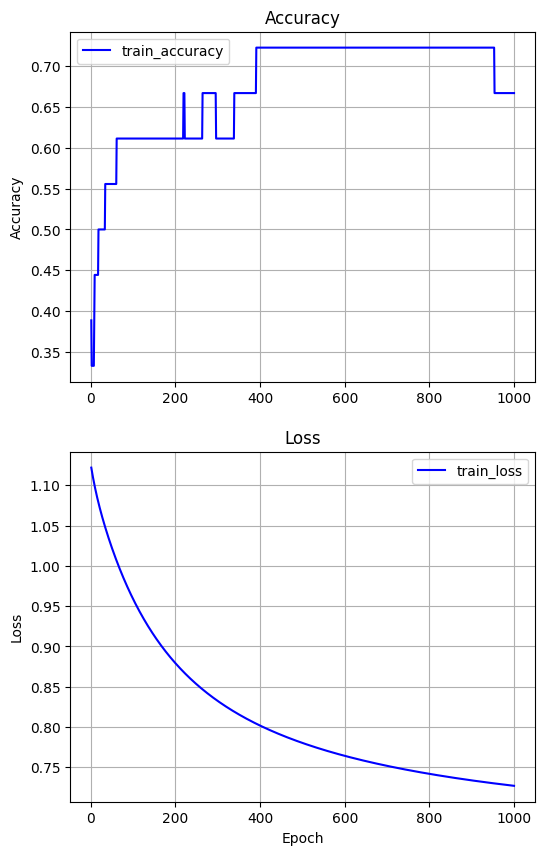

In [10]:
# ============================================
# 8. 학습 결과 그래프 출력
# ============================================

# loss는 모델이 틀린 정도입니다.
# loss는 작아질수록 좋습니다.
#
# accuracy는 모델이 맞힌 비율입니다.
# accuracy는 높아질수록 좋습니다.

loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(6, 10))

# 정확도 그래프
plt.subplot(2, 1, 1)
plt.title('Accuracy')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

# 손실 그래프
plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')

plt.show()

## Training 결과 Test

In [11]:
# ============================================
# 9. 학습 데이터로 예측 결과 확인
# ============================================

# model.predict는 입력값을 넣었을 때
# 모델이 예측한 결과를 출력합니다.
#
# 이 모델의 마지막 층에 softmax가 있으므로,
# H_x에는 3개 클래스에 대한 확률이 들어 있습니다.

H_x = model.predict(x_input)

for x, h, l in zip(x_input_org, H_x, labels):

    # np.argmax(l)
    # 정답 label에서 가장 큰 값의 위치를 찾습니다.
    #
    # 예:
    # [1, 0, 0] → 0번 클래스
    # [0, 1, 0] → 1번 클래스
    # [0, 0, 1] → 2번 클래스

    true_class = np.argmax(l)

    # np.argmax(h)
    # 모델이 예측한 확률 중 가장 큰 값의 위치를 찾습니다.
    #
    # 예:
    # [0.80, 0.15, 0.05] → 0번 클래스
    # [0.10, 0.75, 0.15] → 1번 클래스
    # [0.05, 0.20, 0.75] → 2번 클래스

    pred_class = np.argmax(h)

    print("Age:{}, BMI:{} [정답:{}] => 예측 class:{} / 확률값:{}"
          .format(x[0], x[1], true_class, pred_class, h))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Age:25.0, BMI:22.0 [정답:0] => 예측 class:0 / 확률값:[0.78539145 0.20498867 0.00961991]
Age:25.0, BMI:26.0 [정답:1] => 예측 class:0 / 확률값:[0.60293126 0.3269424  0.07012638]
Age:25.0, BMI:30.0 [정답:2] => 예측 class:1 / 확률값:[0.30949947 0.3486769  0.34182358]
Age:35.0, BMI:22.0 [정답:0] => 예측 class:0 / 확률값:[0.7045483  0.27536502 0.02008662]
Age:35.0, BMI:26.0 [정답:1] => 예측 class:0 / 확률값:[0.48013997 0.38987523 0.12998475]
Age:35.0, BMI:30.0 [정답:0] => 예측 class:2 / 확률값:[0.19019654 0.32086337 0.48894012]
Age:45.0, BMI:22.0 [정답:0] => 예측 class:0 / 확률값:[0.60546434 0.35435697 0.04017868]
Age:45.0, BMI:26.0 [정답:0] => 예측 class:1 / 확률값:[0.35136074 0.42723358 0.22140564]
Age:45.0, BMI:30.0 [정답:1] => 예측 class:2 / 확률값:[0.10515419 0.26564306 0.6292028 ]
Age:55.0, BMI:22.0 [정답:0] => 예측 class:0 / 확률값:[0.49239993 0.43154362 0.07605644]
Age:55.0, BMI:26.0 [정답:1] => 예측 class:1 / 확률값:[0.23323423 0.42467704 0.3420887 ]
Age:55.0, BMI:30.0 [정답:2] => 예측 class:2 / 확률값:[0.053446   0.20218158 0.

## Predict

In [12]:
# ============================================
# 10. 새로운 데이터 예측 함수
# ============================================

def predict(x):

    # 새로운 데이터도 반드시 학습 데이터와 같은 방식으로 정규화해야 합니다.
    #
    # 모델은 이미 정규화된 데이터를 기준으로 학습했습니다.
    # 따라서 새로운 데이터를 원본 그대로 넣으면
    # 모델이 이상하게 예측할 수 있습니다.

    x_scaled = (x - x_min) / (x_max - x_min)

    # 정규화된 데이터를 모델에 넣고 예측합니다.
    # 출력값은 softmax를 거친 확률값입니다.

    return model.predict(x_scaled)


In [13]:
# ============================================
# 11. 테스트 데이터 예측
# ============================================

# 새로운 사람의 데이터입니다.
# 나이 50세, BMI 25인 사람의 혈압 상태를 예측합니다.

x_test = tf.constant([[50.0, 25.0]], dtype=tf.float32)

# 예측 실행
H_x = predict(x_test)

# H_x[0]에는 3개 클래스의 확률이 들어 있습니다.
#
# 예:
# [0.30, 0.55, 0.15]
#
# 정상 확률 30%
# 주의 확률 55%
# 경고 확률 15%
#
# 이 경우 가장 큰 값은 1번 클래스이므로
# 최종 예측은 “주의”가 됩니다.

pred_class = np.argmax(H_x[0])

print("Age : {}, BMI : {} => 예측 Class: {} / 확률값: {}"
      .format(x_test[0, 0], x_test[0, 1], pred_class, H_x[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
Age : 50.0, BMI : 25.0 => 예측 Class: 1 / 확률값: [0.35880578 0.44469154 0.19650263]



이 예제는 혈압 값을 직접 예측하는 문제가 아니라 혈압 상태를 구분하는 문제로 만든 것입니다. 그래서 출력값이 수축기 혈압 120, 이완기 혈압 80처럼 나오는 것이 아니라, 정상, 주의, 경고 중 하나로 나오는 구조입니다.
혈압은 실제 생활에서도 단순히 하나의 숫자보다 상태 등급으로 설명하는 경우가 많습니다. 예를 들어 “정상 범위입니다”, “조금 관리가 필요합니다”, “위험하므로 주의해야 합니다”처럼 단계로 판단합니다. 이 코드에서는 그 개념을 쉽게 실습하기 위해 혈압 상태를 3개 등급으로 나눈 것입니다.
즉, 3개로 나눈 이유는 모델의 출력 목적이 “혈압 수치 예측”이 아니라 “혈압 상태 분류”이기 때문입니다.
왜 Softmax를 사용했는가
이 모델은 정상, 주의, 경고 3개 중 하나를 선택해야 합니다. 이처럼 여러 개의 클래스 중 하나를 고르는 문제를 다중 클래스 분류라고 합니다.
Softmax는 모델의 출력값 3개를 확률처럼 바꿔줍니다.

Sigmoid를 쓰지 않은 이유
Sigmoid는 보통 두 가지 중 하나를 고르는 이진 분류에 많이 사용합니다.
예를 들어 다음과 같은 문제입니다.
고혈압이다 / 아니다
합격이다 / 불합격이다
불량이다 / 정상이다
하지만 이 코드는 정상, 주의, 경고처럼 3개 중 하나를 골라야 합니다. 그래서 Sigmoid보다 Softmax가 더 적합합니다.
정리하면 다음과 같습니다.
Sigmoid는 2개 분류에 적합합니다.
Softmax는 3개 이상 분류에 적합합니다.
이 코드는 혈압 상태를 3개 등급으로 나누었기 때문에 Softmax를 사용합니다.